# 01 — Business Understanding

## Business Question

**Should we increase the subscription price by 10%?**

Before we design any experiment, we need to understand what the business looks like *today*.
This notebook answers two questions:

1. **What does our business currently look like?**
   (customers, revenue, AOV, purchase frequency, CLV, revenue distribution, high-value customer concentration)
2. **If we increase prices, what metrics should we monitor?**
   (primary metric + guardrail metrics)

We use a synthetic subscription dataset (`src/data_processing.py`) that mimics a real product's
billing data — feel free to swap in your own `data/raw/*.csv` and re-run this notebook unchanged.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_processing import BusinessConfig, generate_synthetic_customers, compute_business_metrics, save_processed

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Generate / load the business data

In production, this cell would instead read from `data/raw/`.

In [2]:
config = BusinessConfig(n_customers=20_000, base_price=120.0, seed=42)
customers = generate_synthetic_customers(config)

save_processed(customers, "../data/processed/customers.csv")
customers.head()


,customer_id,plan_tier,tenure_months,orders,order_value,revenue,converted
0,1,Standard,43,1,100.71,100.71,1
1,2,Basic,35,1,121.37,121.37,1
2,3,Premium,10,0,184.63,0.00,0
3,4,Standard,47,1,123.64,123.64,1
4,5,Basic,47,1,97.92,97.92,1


## 2. What does our business look like today?

In [3]:
metrics = compute_business_metrics(customers)

print(f"Customers:              {metrics['n_customers']:,}")
print(f"Total revenue:          ${metrics['total_revenue']:,.0f}")
print(f"Conversion rate:        {metrics['conversion_rate']:.1%}")
print(f"Average order value:    ${metrics['average_order_value']:,.2f}")
print(f"Purchase frequency:     {metrics['purchase_frequency']:.2f} orders/customer")
print(f"Simple CLV estimate:    ${metrics['simple_clv']:,.2f}")
print(f"Top-decile revenue share:{metrics['top_decile_revenue_share']:.1%}")


Customers:              20,000
Total revenue:          $2,660,434
Conversion rate:        68.4%
Average order value:    $115.37
Purchase frequency:     1.15 orders/customer
Simple CLV estimate:    $3,200.02
Top-decile revenue share:33.5%


### Interpretation

- Revenue per customer is our core economic unit — it's what a price change will move directly.
- Purchase frequency tells us how often a "price increase" event is even experienced by a customer.
- The **top-decile revenue share** tells us how concentrated our revenue is: if the top 10% of
  customers drive ~1/3 of revenue, a price change's effect on *that* segment matters disproportionately,
  and we should check our experiment isn't accidentally skewed by a handful of whales.

## 3. Revenue distribution

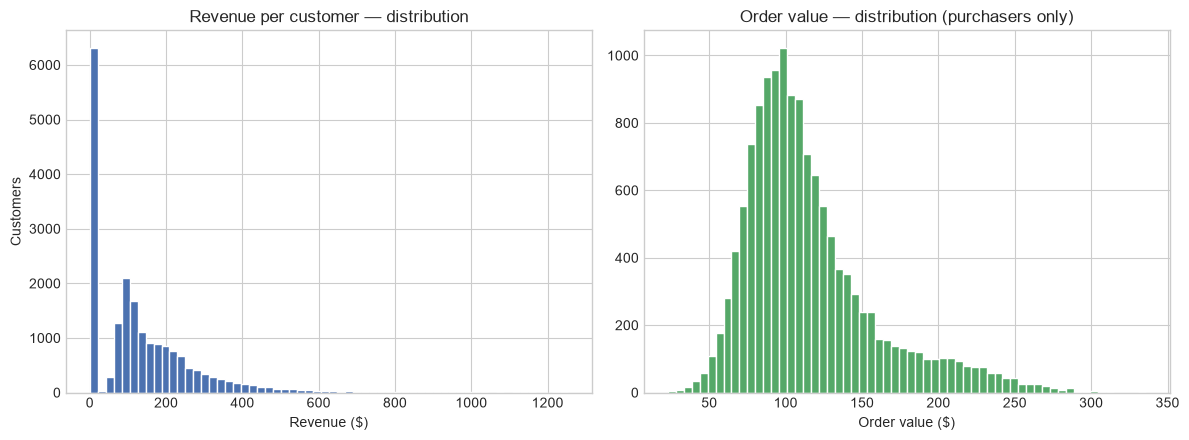

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(customers["revenue"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_title("Revenue per customer — distribution")
axes[0].set_xlabel("Revenue ($)")
axes[0].set_ylabel("Customers")

axes[1].hist(customers.loc[customers["orders"] > 0, "order_value"], bins=60, color="#55A868", edgecolor="white")
axes[1].set_title("Order value — distribution (purchasers only)")
axes[1].set_xlabel("Order value ($)")

plt.tight_layout()
plt.show()


## 4. Revenue by plan tier

In [5]:
tier_summary = (
    customers.groupby("plan_tier")
    .agg(customers=("customer_id", "count"),
         revenue=("revenue", "sum"),
         avg_order_value=("order_value", "mean"),
         conversion_rate=("converted", "mean"))
    .sort_values("revenue", ascending=False)
)
tier_summary["revenue_share"] = tier_summary["revenue"] / tier_summary["revenue"].sum()
tier_summary


,customers,revenue,avg_order_value,conversion_rate,revenue_share
plan_tier,,,,,
Basic,9938,"1,035,884.36",89.53,0.69,0.39
Standard,7090,"968,661.41",119.81,0.68,0.36
Premium,2972,"655,887.76",192.95,0.68,0.25


## 5. If we increase prices, what should we monitor?

**Primary metric**

- **Revenue per customer** — this is the metric the experiment is designed to move, and the one
  tied directly to the business question ("should we raise price?").

**Guardrail metrics** (things that should *not* get meaningfully worse)

- **Conversion rate** — are fewer people purchasing at all?
- **Order count** — are existing customers buying less often?
- **Average basket size / order value** — is the realized price increase actually landing, net of any downgrades?

We'll carry these same four metrics through every remaining notebook so that the "ship / don't ship"
decision in Notebook 4 is never based on the primary metric alone.

## Next: `02_experiment_design.ipynb` — how we'll randomize customers and simulate the price change.